# Звіт Сірошенко практика 3.5

### 2. **Завантаження та попередній перегляд даних

In [4]:
import pandas as pd

df = pd.read_csv('C:/Users/day2026/Documents/MIAZ_2026_work/Theme_3/PR_3.5/data/Summary of Weather.csv')

print(df.head())
print(df.info())

     STA      Date Precip  WindGustSpd    MaxTemp    MinTemp   MeanTemp  \
0  10001  1942-7-1  1.016          NaN  25.555556  22.222222  23.888889   
1  10001  1942-7-2      0          NaN  28.888889  21.666667  25.555556   
2  10001  1942-7-3   2.54          NaN  26.111111  22.222222  24.444444   
3  10001  1942-7-4   2.54          NaN  26.666667  22.222222  24.444444   
4  10001  1942-7-5      0          NaN  26.666667  21.666667  24.444444   

  Snowfall PoorWeather  YR  ...  FB  FTI ITH  PGT  TSHDSBRSGF  SD3  RHX  RHN  \
0      0.0         NaN  42  ... NaN  NaN NaN  NaN         NaN  NaN  NaN  NaN   
1      0.0         NaN  42  ... NaN  NaN NaN  NaN         NaN  NaN  NaN  NaN   
2      0.0         NaN  42  ... NaN  NaN NaN  NaN         NaN  NaN  NaN  NaN   
3      0.0         NaN  42  ... NaN  NaN NaN  NaN         NaN  NaN  NaN  NaN   
4      0.0         NaN  42  ... NaN  NaN NaN  NaN         NaN  NaN  NaN  NaN   

  RVG  WTE  
0 NaN  NaN  
1 NaN  NaN  
2 NaN  NaN  
3 NaN  NaN  
4 N

C:\Users\day2026\AppData\Local\Temp\ipykernel_1944\2770512804.py:3: DtypeWarning: Columns (0: Snowfall, 1: PoorWeather, 2: SNF, 3: TSHDSBRSGF) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('C:/Users/day2026/Documents/MIAZ_2026_work/Theme_3/PR_3.5/data/Summary of Weather.csv')


## 3. **Очищення даних**

In [7]:
# Перевірка на пропущені значення
print(df.isnull().sum())

# Заповнення пропущених значень середнім для числових стовпців
df.fillna(df.select_dtypes(include='number').mean(), inplace=True)

# Видалення дублікатів
df.drop_duplicates(inplace=True)

STA                 0
Date                0
Precip              0
WindGustSpd         0
MaxTemp             0
MinTemp             0
MeanTemp            0
Snowfall         1163
PoorWeather     84797
YR                  0
MO                  0
DA                  0
PRCP             1932
DR                  0
SPD                 0
MAX                 0
MIN                 0
MEA                 0
SNF              1163
SND                 0
FT             119030
FB             119030
FTI            119030
ITH            119030
PGT                 0
TSHDSBRSGF      84797
SD3            119030
RHX            119030
RHN            119030
RVG            119030
WTE            119030
dtype: int64


## 4. **Трансформація даних**

In [16]:
from sklearn.preprocessing import MinMaxScaler

# Колонки, які будемо нормалізувати
numerical_columns = [
    'Precip',
    'WindGustSpd',
    'MaxTemp',
    'MinTemp',
    'MeanTemp',
    'Snowfall'
]

# Замінюємо 'T' (Trace) на 0
df_transformed = df.copy()

df_transformed['Precip'] = df_transformed['Precip'].replace('T', 0)
df_transformed['Snowfall'] = df_transformed['Snowfall'].replace('T', 0)

# Перетворюємо вибрані колонки на числовий тип
for column in numerical_columns:
    df_transformed[column] = pd.to_numeric(
        df_transformed[column],
        errors='coerce'
    )

# Заповнюємо можливі пропущені значення середнім
for column in numerical_columns:
    df_transformed[column] = df_transformed[column].fillna(
        df_transformed[column].mean()
    )

# Нормалізація
scaler = MinMaxScaler()

df_transformed[numerical_columns] = scaler.fit_transform(
    df_transformed[numerical_columns]
)

# Перегляд результату
print(df_transformed.head())

     STA      Date    Precip  WindGustSpd   MaxTemp   MinTemp  MeanTemp  \
0  10001  1942-7-1  0.003306     0.335375  0.706667  0.832061  0.786765   
1  10001  1942-7-2  0.000000     0.335375  0.746667  0.824427  0.808824   
2  10001  1942-7-3  0.008264     0.335375  0.713333  0.832061  0.794118   
3  10001  1942-7-4  0.008264     0.335375  0.720000  0.832061  0.794118   
4  10001  1942-7-5  0.000000     0.335375  0.720000  0.824427  0.794118   

   Snowfall PoorWeather  YR  ...  FB  FTI ITH        PGT  TSHDSBRSGF  SD3  \
0       0.0         NaN  42  ... NaN  NaN NaN  12.085333         NaN  NaN   
1       0.0         NaN  42  ... NaN  NaN NaN  12.085333         NaN  NaN   
2       0.0         NaN  42  ... NaN  NaN NaN  12.085333         NaN  NaN   
3       0.0         NaN  42  ... NaN  NaN NaN  12.085333         NaN  NaN   
4       0.0         NaN  42  ... NaN  NaN NaN  12.085333         NaN  NaN   

   RHX  RHN RVG  WTE  
0  NaN  NaN NaN  NaN  
1  NaN  NaN NaN  NaN  
2  NaN  NaN NaN  

## 5. **Декомпозиція набору даних**

In [18]:
from sklearn.model_selection import train_test_split

# Поділ на навчальну та тестову вибірки
train_set, test_set = train_test_split(
    df_transformed,
    test_size=0.2,
    random_state=42
)

# Кореляційна матриця тільки для числових змінних
correlation_matrix = df_transformed.select_dtypes(
    include='number'
).corr()

print(correlation_matrix)

                  STA    Precip   WindGustSpd   MaxTemp   MinTemp  MeanTemp  \
STA          1.000000  0.013391 -9.263608e-03  0.092360  0.059318  0.078105   
Precip       0.013391  1.000000  3.141746e-02  0.004475  0.088457  0.047071   
WindGustSpd -0.009264  0.031417  1.000000e+00 -0.002390  0.014518  0.006017   
MaxTemp      0.092360  0.004475 -2.389891e-03  1.000000  0.878408  0.969054   
MinTemp      0.059318  0.088457  1.451802e-02  0.878408  1.000000  0.965432   
MeanTemp     0.078105  0.047071  6.016595e-03  0.969054  0.965432  1.000000   
Snowfall    -0.058258 -0.011188 -9.439750e-15 -0.324365 -0.309966 -0.325965   
YR           0.121395  0.008974  2.929897e-14  0.039520 -0.020742  0.010642   
MO          -0.008588  0.037798  8.736181e-03  0.031361  0.069080  0.050778   
DA           0.000883  0.000619  1.400868e-04 -0.005196 -0.002585 -0.004192   
DR          -0.014049  0.026010  3.509761e-01  0.000228  0.024466  0.012430   
SPD         -0.009264  0.031417  1.000000e+00 -0.002

## 6. **Описова статистика та візуалізація**

                 STA         Precip    WindGustSpd        MaxTemp  \
count  119030.000000  119030.000000  119030.000000  119030.000000   
mean    29659.059456       0.010496       0.335375       0.724535   
std     20954.049325       0.035145       0.011980       0.104615   
min     10001.000000       0.000000       0.000000       0.000000   
25%     11801.000000       0.000000       0.335375       0.706667   
50%     22508.000000       0.000000       0.335375       0.753333   
75%     33501.000000       0.002479       0.335375       0.780000   
max     82506.000000       1.000000       1.000000       1.000000   

             MinTemp       MeanTemp       Snowfall             YR  \
count  119030.000000  119030.000000  119030.000000  119030.000000   
mean        0.771153       0.767209       0.002843      43.805184   
std         0.114525       0.109830       0.030261       1.136713   
min         0.000000       0.000000       0.000000      40.000000   
25%         0.732824       0.7426

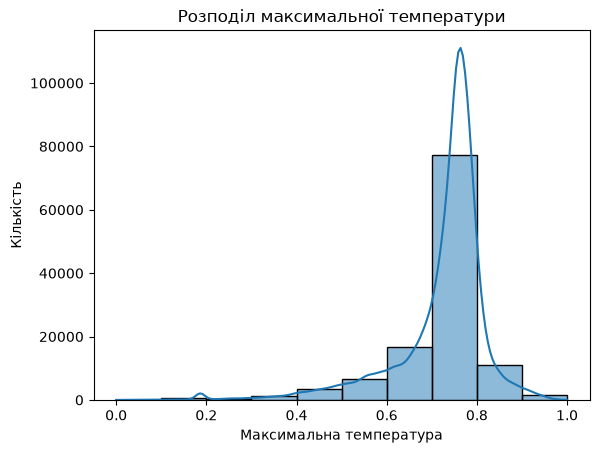

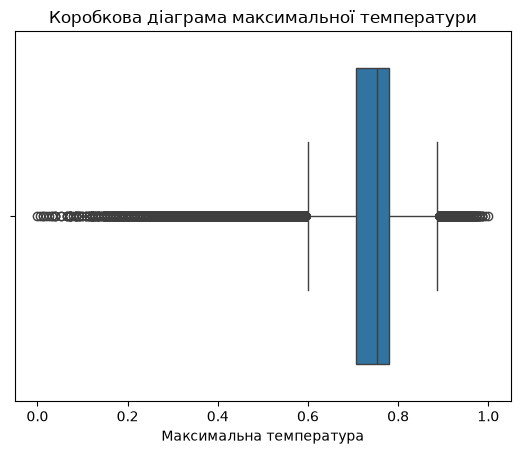

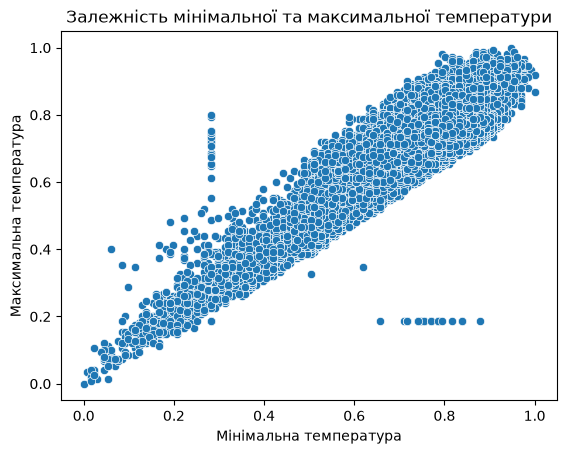

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Описова статистика тільки для числових змінних
print(df_transformed.describe())

# Гістограма для максимальної температури
sns.histplot(df_transformed['MaxTemp'], bins=10, kde=True)
plt.title('Розподіл максимальної температури')
plt.xlabel('Максимальна температура')
plt.ylabel('Кількість')
plt.show()

# Коробкова діаграма для максимальної температури
sns.boxplot(x=df_transformed['MaxTemp'])
plt.title('Коробкова діаграма максимальної температури')
plt.xlabel('Максимальна температура')
plt.show()

# Діаграма розсіювання MinTemp та MaxTemp
sns.scatterplot(
    x=df_transformed['MinTemp'],
    y=df_transformed['MaxTemp']
)
plt.title('Залежність мінімальної та максимальної температури')
plt.xlabel('Мінімальна температура')
plt.ylabel('Максимальна температура')
plt.show()

## 7. **Побудова моделі**

In [22]:
from sklearn.linear_model import LinearRegression

# Ознаки (features)
features = ['MinTemp', 'WindGustSpd']

# Цільова змінна (target)
target = 'MaxTemp'

# Створення моделі
model = LinearRegression()

# Навчання моделі
model.fit(
    train_set[features],
    train_set[target]
)

# Прогноз на тестовій вибірці
predictions = model.predict(test_set[features])

# Виведення прогнозів
print("Прогнози:")
print(predictions)

Прогнози:
[0.77951958 0.78565318 0.5341753  ... 0.59551137 0.71818351 0.77951958]
